# Transfer Learning: Klasifikasi Sampah dengan ResNet18

Notebook ini mengimplementasikan **Transfer Learning** menggunakan **ResNet18** (pre-trained ImageNet) untuk mengklasifikasikan gambar sampah ke 6 kategori: *cardboard, glass, metal, paper, plastic, trash*.

**Alur:**
1. Load ResNet18 pre-trained → freeze semua layer Conv
2. Ganti FC terakhir → output 6 kelas
3. **Fase 1**: Latih hanya FC baru (Fixed Feature Extractor)
4. **Fase 2**: Unfreeze `layer4` → Fine-tuning dengan LR kecil
5. Evaluasi & analisis overfitting

> Ubah `DATASET_DIR` agar menunjuk ke folder `TrashType_Image_Dataset`.


## 0. Import & Konfigurasi

In [1]:
import os, random, glob
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from PIL import Image

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── Konfigurasi ──────────────────────────────────────────────────────────────
DATASET_DIR = "dataset/TrashType_Image_Dataset"
IMG_SIZE    = 224        # standar ResNet18 / ImageNet
BATCH_SIZE  = 32


Device: cpu


## STEP 1 — Preprocessing & Data Loading

ResNet18 dilatih dengan normalisasi ImageNet spesifik — kita **wajib** memakai nilai yang sama agar bobot pre-trained bekerja optimal.

- **Train**: resize + augmentasi (flip, rotasi, color jitter) + normalize
- **Val/Test**: resize + normalize saja (tanpa augmentasi agar evaluasi konsisten)


In [2]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Load dataset & split 80/10/10
full_raw  = datasets.ImageFolder(root=DATASET_DIR, transform=train_transform)
full_vt   = datasets.ImageFolder(root=DATASET_DIR, transform=val_test_transform)
class_names = full_raw.classes
num_classes = len(class_names)

n_total = len(full_raw)
n_train = int(0.8 * n_total)
n_val   = int(0.1 * n_total)
n_test  = n_total - n_train - n_val

idx = list(range(n_total)); random.shuffle(idx)
train_set = Subset(full_raw, idx[:n_train])
val_set   = Subset(full_vt,  idx[n_train:n_train+n_val])
test_set  = Subset(full_vt,  idx[n_train+n_val:])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Kelas  : {class_names}")
print(f"Total  : {n_total}  |  Train: {n_train}  Val: {n_val}  Test: {n_test}")


Kelas  : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'tesfolder', 'trash']
Total  : 2548  |  Train: 2038  Val: 254  Test: 256


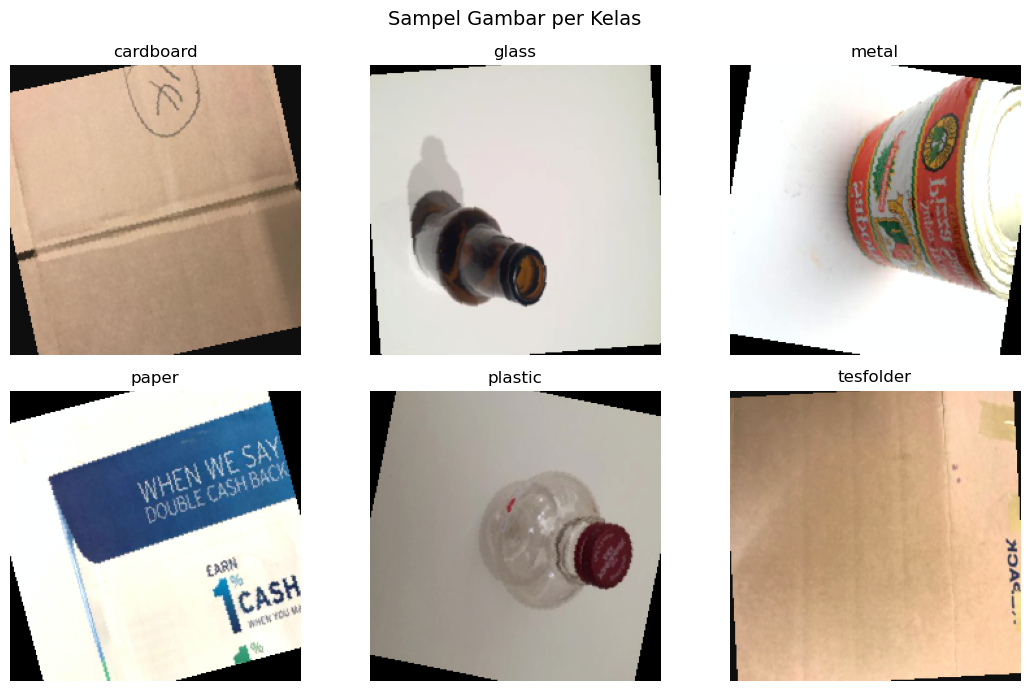

In [3]:
# Visualisasi 1 sampel per kelas
def imshow_imagenet(t):
    img = t.numpy().transpose(1,2,0)
    img = np.array([0.229,0.224,0.225]) * img + np.array([0.485,0.456,0.406])
    return np.clip(img, 0, 1)

shown = {}
for img, label in full_raw:
    cls = class_names[label]
    if cls not in shown:
        shown[cls] = img
    if len(shown) == num_classes:
        break

cols, rows = 3, 2
fig, axes = plt.subplots(rows, cols, figsize=(11, 7))
axes = axes.flatten()
for i, (cls, img) in enumerate(shown.items()):
    if i >= len(axes):
        break
    axes[i].imshow(imshow_imagenet(img))
    axes[i].set_title(cls, fontsize=12)
    axes[i].axis("off")
for j in range(min(len(shown), len(axes)), len(axes)):
    axes[j].axis("off")
plt.suptitle("Sampel Gambar per Kelas", fontsize=14)
plt.tight_layout(); plt.show()


## STEP 2 — Transfer Learning: Load & Modifikasi ResNet18

**ResNet18** memiliki 18 layer dengan *skip connections* yang mencegah vanishing gradient. Pre-trained pada 1,2 juta gambar ImageNet (1000 kelas).

Langkah modifikasi:
1. **Freeze** semua layer Conv → dijadikan fixed feature extractor
2. **Ganti** layer `fc` terakhir: `FC(512→1000)` → `FC(512→256→6)` + Dropout + BatchNorm

```
Conv Layers (FROZEN)  →  AdaptiveAvgPool  →  FC(512→256)→BN→ReLU→Dropout(0.5)→FC(256→6)
```


In [4]:
# Load ResNet18 pre-trained
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze semua layer
for param in model.parameters():
    param.requires_grad = False

# Ganti FC terakhir
in_features = model.fc.in_features   # 512
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)
)
model = model.to(device)

# Ringkasan parameter
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameter    : {total:,}")
print(f"Trainable (FC baru): {trainable:,}  ({trainable/total*100:.1f}%)")
print(f"Frozen (Conv)      : {total-trainable:,}  ({(total-trainable)/total*100:.1f}%)")
print(f"\nArsitektur FC baru:\n{model.fc}")


Total parameter    : 11,310,151
Trainable (FC baru): 133,639  (1.2%)
Frozen (Conv)      : 11,176,512  (98.8%)

Arsitektur FC baru:
Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=256, out_features=7, bias=True)
)


## STEP 3 — Training Fase 1: Fixed Feature Extractor

Hanya layer FC baru yang dilatih. Layer Conv tetap beku sehingga fitur ImageNet tidak rusak.

Teknik regularisasi yang digunakan:
- **Dropout(0.5)** — nonaktifkan 50% neuron acak → cegah overfitting
- **BatchNorm1d** — normalisasi aktivasi → training lebih stabil
- **Weight Decay (L2 = 1e-4)** — penalti bobot besar
- **ReduceLROnPlateau** — turunkan LR jika val_acc stagnan
- **Early Stopping** — hentikan jika tidak ada perbaikan selama 5 epoch
- **Best Model Checkpoint** — simpan bobot terbaik berdasarkan val_acc


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

NUM_EPOCHS = 15
PATIENCE   = 5
best_val_acc, patience_cnt = 0.0, 0
history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}

print("=== Fase 1: Fixed Feature Extractor ===\n")

for epoch in range(NUM_EPOCHS):
    model.train()
    run_loss, correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        run_loss += loss.item() * imgs.size(0)
        correct  += (out.argmax(1) == labels).sum().item()
        total    += labels.size(0)
    tr_loss, tr_acc = run_loss/total, correct/total

    model.eval()
    vl_sum, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out  = model(imgs)
            vl_sum += criterion(out, labels).item() * imgs.size(0)
            vc     += (out.argmax(1) == labels).sum().item()
            vt     += labels.size(0)
    vl_loss, vl_acc = vl_sum/vt, vc/vt

    history["train_loss"].append(tr_loss); history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(vl_acc)
    scheduler.step(vl_acc)

    mark = ""
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), "best_phase1.pth")
        mark = " ✓"; patience_cnt = 0
    else:
        patience_cnt += 1

    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}] "
          f"Train {tr_loss:.4f}/{tr_acc:.4f} | Val {vl_loss:.4f}/{vl_acc:.4f}{mark}")
    if patience_cnt >= PATIENCE:
        print("Early stopping."); break

print(f"\nBest Val Acc Fase 1: {best_val_acc:.4f}")


=== Fase 1: Fixed Feature Extractor ===

Epoch [ 1/15] Train 1.0626/0.6330 | Val 0.6116/0.8150 ✓
Epoch [ 2/15] Train 0.6916/0.7689 | Val 0.5277/0.8465 ✓
Epoch [ 3/15] Train 0.6172/0.7890 | Val 0.4881/0.8661 ✓
Epoch [ 4/15] Train 0.5435/0.8184 | Val 0.5110/0.8386
Epoch [ 5/15] Train 0.5060/0.8194 | Val 0.4977/0.8583
Epoch [ 6/15] Train 0.4983/0.8234 | Val 0.4514/0.8661
Epoch [ 7/15] Train 0.4739/0.8366 | Val 0.4548/0.8661
Epoch [ 8/15] Train 0.4341/0.8489 | Val 0.4556/0.8858 ✓
Epoch [ 9/15] Train 0.4081/0.8602 | Val 0.4484/0.8780
Epoch [10/15] Train 0.3972/0.8572 | Val 0.4521/0.8937 ✓
Epoch [11/15] Train 0.3825/0.8606 | Val 0.4509/0.8780
Epoch [12/15] Train 0.4020/0.8651 | Val 0.4254/0.8819
Epoch [13/15] Train 0.3686/0.8724 | Val 0.4304/0.8780
Epoch [14/15] Train 0.3453/0.8788 | Val 0.4466/0.8819
Epoch [15/15] Train 0.3333/0.8911 | Val 0.4199/0.8858
Early stopping.

Best Val Acc Fase 1: 0.8937


## STEP 4 — Fine-tuning Fase 2: Unfreeze layer4

Load bobot terbaik Fase 1, kemudian unfreeze `layer4` ResNet18 agar fitur tingkat tinggi ikut menyesuaikan dataset sampah. Gunakan **LR sangat kecil (1e-4)** agar bobot pre-trained tidak rusak.

```
Layer1-3  : FROZEN  (fitur dasar: edges, textures)
Layer4    : TRAINABLE  (fitur tingkat tinggi: objek spesifik)
FC (baru) : TRAINABLE
```


In [6]:
# Load bobot terbaik Fase 1
model.load_state_dict(torch.load("best_phase1.pth", map_location=device))

# Unfreeze layer4 + FC
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True

trainable_ft = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameter trainable Fase 2: {trainable_ft:,}")

optimizer_ft = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-4
)
scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft, mode="max", factor=0.5, patience=3
)

NUM_EPOCHS_FT = 10
PATIENCE_FT   = 4
best_val_acc_ft, patience_cnt_ft = 0.0, 0
history_ft = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}

print("\n=== Fase 2: Fine-tuning (layer4 + FC) ===\n")

for epoch in range(NUM_EPOCHS_FT):
    model.train()
    run_loss, correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer_ft.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward(); optimizer_ft.step()
        run_loss += loss.item() * imgs.size(0)
        correct  += (out.argmax(1) == labels).sum().item()
        total    += labels.size(0)
    tr_loss, tr_acc = run_loss/total, correct/total

    model.eval()
    vl_sum, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out  = model(imgs)
            vl_sum += criterion(out, labels).item() * imgs.size(0)
            vc     += (out.argmax(1) == labels).sum().item()
            vt     += labels.size(0)
    vl_loss, vl_acc = vl_sum/vt, vc/vt

    history_ft["train_loss"].append(tr_loss); history_ft["val_loss"].append(vl_loss)
    history_ft["train_acc"].append(tr_acc);   history_ft["val_acc"].append(vl_acc)
    scheduler_ft.step(vl_acc)

    gap  = tr_acc - vl_acc
    warn = f" ⚠gap={gap:.3f}" if gap > 0.10 else ""
    mark = ""
    if vl_acc > best_val_acc_ft:
        best_val_acc_ft = vl_acc
        torch.save(model.state_dict(), "best_finetune.pth")
        mark = " ✓"; patience_cnt_ft = 0
    else:
        patience_cnt_ft += 1

    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS_FT}] "
          f"Train {tr_loss:.4f}/{tr_acc:.4f} | Val {vl_loss:.4f}/{vl_acc:.4f}{mark}{warn}")
    if patience_cnt_ft >= PATIENCE_FT:
        print("Early stopping."); break

print(f"\nBest Val Acc Fase 2: {best_val_acc_ft:.4f}")


Parameter trainable Fase 2: 8,527,367

=== Fase 2: Fine-tuning (layer4 + FC) ===

Epoch [ 1/10] Train 0.4362/0.8499 | Val 0.3958/0.8819 ✓
Epoch [ 2/10] Train 0.2677/0.9127 | Val 0.3737/0.8858 ✓
Epoch [ 3/10] Train 0.2041/0.9352 | Val 0.4253/0.8858
Epoch [ 4/10] Train 0.1677/0.9509 | Val 0.3206/0.9016 ✓
Epoch [ 5/10] Train 0.1289/0.9632 | Val 0.3432/0.9055 ✓
Epoch [ 6/10] Train 0.1062/0.9686 | Val 0.3319/0.9134 ✓
Epoch [ 7/10] Train 0.0942/0.9740 | Val 0.3449/0.9055
Epoch [ 8/10] Train 0.0868/0.9769 | Val 0.3361/0.9055
Epoch [ 9/10] Train 0.0728/0.9818 | Val 0.3612/0.8976
Epoch [10/10] Train 0.0765/0.9809 | Val 0.3806/0.9055
Early stopping.

Best Val Acc Fase 2: 0.9134


## STEP 5 — Visualisasi Training & Analisis Overfitting

Grafik menampilkan loss dan akurasi kedua fase. Garis vertikal menandai batas Fase 1 → Fase 2.

**Cara baca:**
- Val Loss < Train Loss → model belum overfitting (atau underfitting)
- Train Acc >> Val Acc (gap > 10%) → tanda overfitting


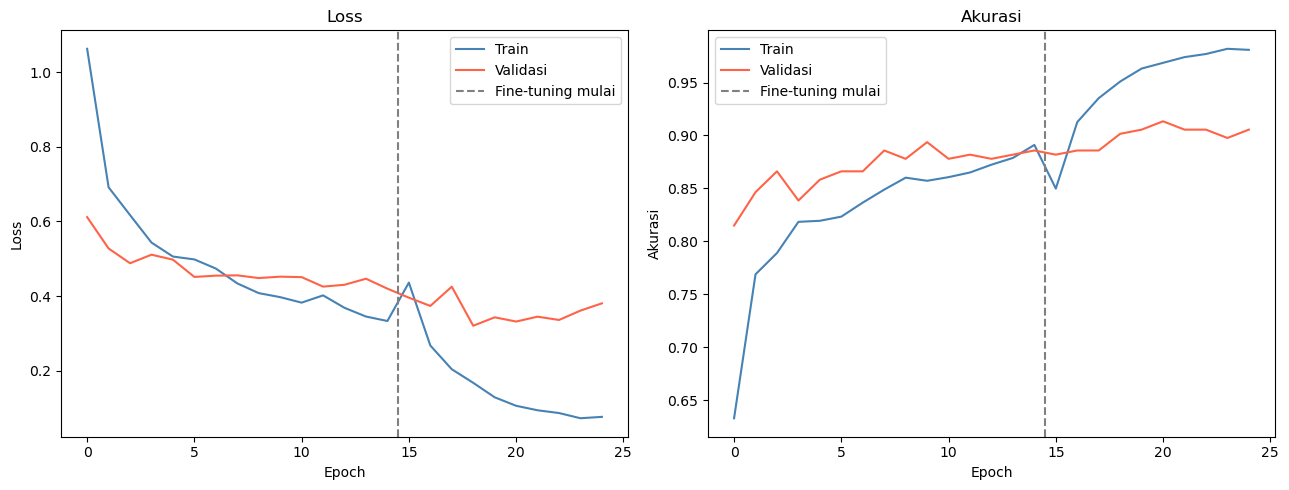


=== Analisis Overfitting Fase 2 ===
Epoch | Train Acc |  Val Acc |     Gap | Status
----------------------------------------------------
    1 |    0.8499 |   0.8819 | -0.0320 | ✓ seimbang
    2 |    0.9127 |   0.8858 | +0.0268 | ✓ seimbang
    3 |    0.9352 |   0.8858 | +0.0494 | ✓ seimbang
    4 |    0.9509 |   0.9016 | +0.0494 | ✓ seimbang
    5 |    0.9632 |   0.9055 | +0.0577 | ✓ seimbang
    6 |    0.9686 |   0.9134 | +0.0552 | ✓ seimbang
    7 |    0.9740 |   0.9055 | +0.0685 | ✓ seimbang
    8 |    0.9769 |   0.9055 | +0.0714 | ✓ seimbang
    9 |    0.9818 |   0.8976 | +0.0842 | ✓ seimbang
   10 |    0.9809 |   0.9055 | +0.0754 | ✓ seimbang

Rata-rata gap: +0.0506
-> Model SEIMBANG. Training berhasil!


In [7]:
# Gabung history dua fase
all_tl = history["train_loss"] + history_ft["train_loss"]
all_vl = history["val_loss"]   + history_ft["val_loss"]
all_ta = history["train_acc"]  + history_ft["train_acc"]
all_va = history["val_acc"]    + history_ft["val_acc"]
n1     = len(history["train_loss"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, tr, vl, title, ylabel in [
    (axes[0], all_tl, all_vl, "Loss",    "Loss"),
    (axes[1], all_ta, all_va, "Akurasi", "Akurasi")
]:
    ax.plot(tr, label="Train",    color="steelblue")
    ax.plot(vl, label="Validasi", color="tomato")
    ax.axvline(n1 - 0.5, color="gray", linestyle="--", label="Fine-tuning mulai")
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout(); plt.show()

# ── Tabel analisis overfitting Fase 2 ────────────────────────────────────────
print("\n=== Analisis Overfitting Fase 2 ===")
print(f"{'Epoch':>5} | {'Train Acc':>9} | {'Val Acc':>8} | {'Gap':>7} | Status")
print("-" * 52)
for i, (ta, va) in enumerate(zip(history_ft["train_acc"], history_ft["val_acc"])):
    gap    = ta - va
    status = "⚠ overfitting" if gap > 0.10 else ("↓ underfitting" if gap < -0.05 else "✓ seimbang")
    print(f"{i+1:>5} | {ta:>9.4f} | {va:>8.4f} | {gap:>+7.4f} | {status}")

avg_gap = sum(t-v for t,v in zip(history_ft["train_acc"], history_ft["val_acc"])) / len(history_ft["train_acc"])
print(f"\nRata-rata gap: {avg_gap:+.4f}")
if   avg_gap >  0.10: print("-> OVERFITTING: naikkan Dropout, kurangi epoch, tambah augmentasi.")
elif avg_gap < -0.05: print("-> UNDERFITTING: unfreeze layer3, tambah epoch.")
else:                 print("-> Model SEIMBANG. Training berhasil!")


## STEP 6 — Evaluasi pada Test Set

Load model terbaik (hasil fine-tuning) dan evaluasi pada data test yang belum pernah dilihat selama training.


Test Accuracy: 0.8906 (89.06%)

              precision    recall  f1-score   support

   cardboard       0.93      0.91      0.92        46
       glass       0.96      0.88      0.91        49
       metal       0.87      0.95      0.91        42
       paper       0.91      0.96      0.94        54
     plastic       0.83      0.87      0.85        46
   tesfolder       0.00      0.00      0.00         3
       trash       0.73      0.69      0.71        16

    accuracy                           0.89       256
   macro avg       0.75      0.75      0.75       256
weighted avg       0.88      0.89      0.89       256



/home/hisyam/Downloads/enter/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hisyam/Downloads/enter/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hisyam/Downloads/enter/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

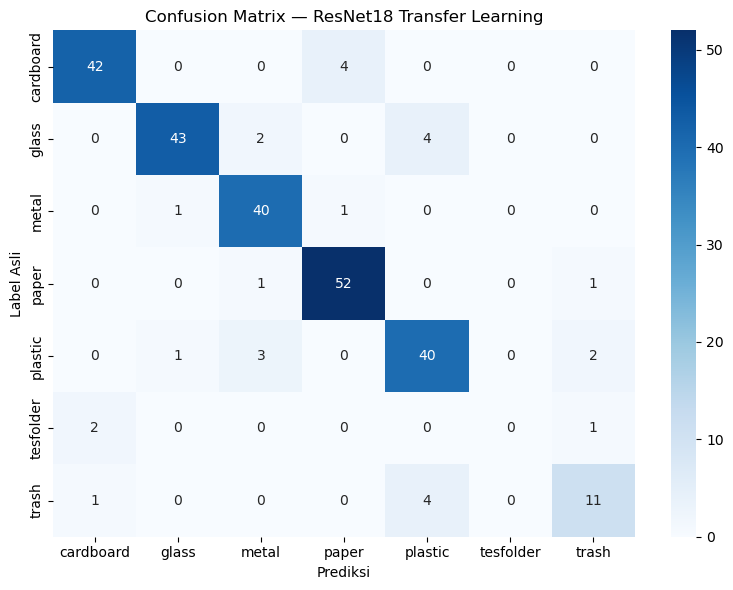

In [8]:
model.load_state_dict(torch.load("best_finetune.pth", map_location=device))
model.eval()
all_preds, all_labels_list = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_list.extend(labels.numpy())

test_acc = (np.array(all_preds) == np.array(all_labels_list)).mean()
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)\n")
print(classification_report(all_labels_list, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels_list, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Prediksi"); plt.ylabel("Label Asli")
plt.title("Confusion Matrix — ResNet18 Transfer Learning")
plt.tight_layout(); plt.show()


## STEP 7 — Inferensi pada Gambar Baru

Uji model dengan gambar baru. Ubah `TEST_IMAGE_PATH` ke path foto sampah kamu.


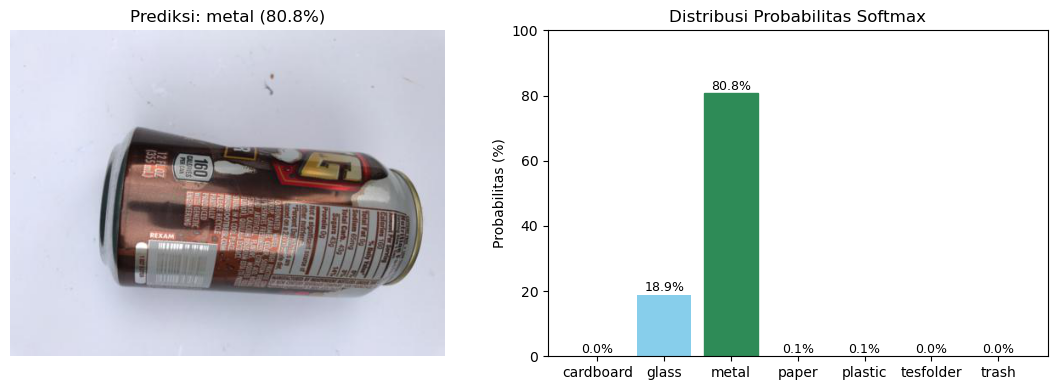

In [10]:
TEST_IMAGE_PATH = "imagetestrash.jpg"   # <-- ganti path gambar kamu

def predict_single(path):
    img        = Image.open(path).convert("RGB")
    img_tensor = val_test_transform(img)
    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(img_tensor.unsqueeze(0).to(device)), dim=1).cpu().numpy()[0]
    return img, probs, probs.argmax()

img, probs, pred_idx = predict_single(TEST_IMAGE_PATH)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(img)
axes[0].set_title(f"Prediksi: {class_names[pred_idx]} ({probs[pred_idx]*100:.1f}%)")
axes[0].axis("off")

bars = axes[1].bar(class_names, probs*100, color="skyblue")
bars[pred_idx].set_color("seagreen")
axes[1].set_ylabel("Probabilitas (%)"); axes[1].set_ylim(0, 100)
axes[1].set_title("Distribusi Probabilitas Softmax")
for i, p in enumerate(probs*100):
    axes[1].text(i, p+1, f"{p:.1f}%", ha="center", fontsize=9)
plt.tight_layout(); plt.show()


---
## Ringkasan

| Aspek | CNN Scratch | Transfer Learning (ResNet18) |
|---|---|---|
| Arsitektur | 3 Conv custom | ResNet18 (18 layer, skip connections) |
| Bobot awal | Random | Pre-trained ImageNet (1,2 juta gambar) |
| Input size | 128×128 | 224×224 |
| Training | 1 fase | 2 fase: Fixed Extractor → Fine-tuning |
| Regularisasi | Dropout | Dropout + BatchNorm + Weight Decay |
| Early Stopping | ✓ | ✓ |
| Ekspektasi akurasi | ~70% | >85% |
